In [1]:
%pip install -q pandas
import pandas as pd
import numpy as np
%pip install -q matplotlib
import matplotlib.pyplot as plt
%pip install -q seaborn
import seaborn as sns
import os
%pip install -q scipy
import scipy.stats as stats
%pip install -q statsmodels
import statsmodels.api as sm
%pip install -q scikit-learn
import sklearn as skl


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [4]:
#read all files into pandas dataframes
campaign_desc = pd.read_csv('campaign_desc.csv')
campaign_table = pd.read_csv('campaign_table.csv')
causal_data = pd.read_csv('causal_data.csv')
coupon_redemption = pd.read_csv('coupon_redempt.csv')
coupon_table = pd.read_csv('coupon.csv')
hh_demographic = pd.read_csv('hh_demographic.csv')
product = pd.read_csv('product.csv')
transaction_data = pd.read_csv('transaction_data.csv')

In [5]:
#explore campaign data
campaign_desc.info()
campaign_desc.head(n=5)

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   DESCRIPTION  30 non-null     str  
 1   CAMPAIGN     30 non-null     int64
 2   START_DAY    30 non-null     int64
 3   END_DAY      30 non-null     int64
dtypes: int64(3), str(1)
memory usage: 1.1 KB


,DESCRIPTION,CAMPAIGN,START_DAY,END_DAY
0,TypeB,24,659,719
1,TypeC,15,547,708
2,TypeB,25,659,691
3,TypeC,20,615,685
4,TypeB,23,646,684


In [6]:
#explore campaign_table data
campaign_table.info()
campaign_table.head(n=5)

<class 'pandas.DataFrame'>
RangeIndex: 7208 entries, 0 to 7207
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   DESCRIPTION    7208 non-null   str  
 1   household_key  7208 non-null   int64
 2   CAMPAIGN       7208 non-null   int64
dtypes: int64(2), str(1)
memory usage: 169.1 KB


,DESCRIPTION,household_key,CAMPAIGN
0,TypeA,17,26
1,TypeA,27,26
2,TypeA,212,26
3,TypeA,208,26
4,TypeA,192,26


In [7]:
#explore causal data
causal_data.info()
causal_data.sort_values(by='WEEK_NO', ascending=True).head(n=5)

<class 'pandas.DataFrame'>
RangeIndex: 36786524 entries, 0 to 36786523
Data columns (total 5 columns):
 #   Column      Dtype
---  ------      -----
 0   PRODUCT_ID  int64
 1   STORE_ID    int64
 2   WEEK_NO     int64
 3   display     str  
 4   mailer      str  
dtypes: int64(3), str(2)
memory usage: 1.4 GB


,PRODUCT_ID,STORE_ID,WEEK_NO,display,mailer
398197,36413,403,9,1,0
4413866,669453,339,9,0,A
5323711,825616,333,9,7,0
12736400,1027829,363,9,0,A
11110195,983665,292,9,6,0


In [8]:
# explore coupon redemption data
coupon_redemption.info()
coupon_redemption.sort_values(by='DAY', ascending=True).head(n=5)

<class 'pandas.DataFrame'>
RangeIndex: 2318 entries, 0 to 2317
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   household_key  2318 non-null   int64
 1   DAY            2318 non-null   int64
 2   COUPON_UPC     2318 non-null   int64
 3   CAMPAIGN       2318 non-null   int64
dtypes: int64(4)
memory usage: 72.6 KB


,household_key,DAY,COUPON_UPC,CAMPAIGN
2007,2280,225,57008510075,26
1987,2240,226,53600000001,26
716,788,227,51111076635,26
717,788,227,55100055008,26
718,788,227,57218020076,26


In [9]:
#explore coupon table data
coupon_table.info()
coupon_table.head(n=5)

<class 'pandas.DataFrame'>
RangeIndex: 124548 entries, 0 to 124547
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   COUPON_UPC  124548 non-null  int64
 1   PRODUCT_ID  124548 non-null  int64
 2   CAMPAIGN    124548 non-null  int64
dtypes: int64(3)
memory usage: 2.9 MB


,COUPON_UPC,PRODUCT_ID,CAMPAIGN
0,10000089061,27160,4
1,10000089064,27754,9
2,10000089073,28897,12
3,51800009050,28919,28
4,52100000076,28929,25


In [10]:
#explore hh_demographic data
hh_demographic.info()
hh_demographic.head(n=5)

<class 'pandas.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   AGE_DESC             801 non-null    str  
 1   MARITAL_STATUS_CODE  801 non-null    str  
 2   INCOME_DESC          801 non-null    str  
 3   HOMEOWNER_DESC       801 non-null    str  
 4   HH_COMP_DESC         801 non-null    str  
 5   HOUSEHOLD_SIZE_DESC  801 non-null    str  
 6   KID_CATEGORY_DESC    801 non-null    str  
 7   household_key        801 non-null    int64
dtypes: int64(1), str(7)
memory usage: 50.2 KB


,AGE_DESC,MARITAL_STATUS_CODE,INCOME_DESC,HOMEOWNER_DESC,HH_COMP_DESC,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC,household_key
0,65+,A,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown,1
1,45-54,A,50-74K,Homeowner,2 Adults No Kids,2,None/Unknown,7
2,25-34,U,25-34K,Unknown,2 Adults Kids,3,1,8
3,25-34,U,75-99K,Homeowner,2 Adults Kids,4,2,13
4,45-54,B,50-74K,Homeowner,Single Female,1,None/Unknown,16


In [11]:
#explore product data
product.info()
product.head(n=5)

<class 'pandas.DataFrame'>
RangeIndex: 92353 entries, 0 to 92352
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   PRODUCT_ID            92353 non-null  int64
 1   MANUFACTURER          92353 non-null  int64
 2   DEPARTMENT            92353 non-null  str  
 3   BRAND                 92353 non-null  str  
 4   COMMODITY_DESC        92353 non-null  str  
 5   SUB_COMMODITY_DESC    92353 non-null  str  
 6   CURR_SIZE_OF_PRODUCT  92353 non-null  str  
dtypes: int64(2), str(5)
memory usage: 4.9 MB


,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,25671,2,GROCERY,National,FRZN ICE,ICE - CRUSHED/CUBED,22 LB
1,26081,2,MISC. TRANS.,National,NO COMMODITY DESCRIPTION,NO SUBCOMMODITY DESCRIPTION,
2,26093,69,PASTRY,Private,BREAD,BREAD:ITALIAN/FRENCH,
3,26190,69,GROCERY,Private,FRUIT - SHELF STABLE,APPLE SAUCE,50 OZ
4,26355,69,GROCERY,Private,COOKIES/CONES,SPECIALTY COOKIES,14 OZ


In [12]:
#explore transaction data
transaction_data.info()
transaction_data.head(n=5)

<class 'pandas.DataFrame'>
RangeIndex: 2595732 entries, 0 to 2595731
Data columns (total 12 columns):
 #   Column             Dtype  
---  ------             -----  
 0   household_key      int64  
 1   BASKET_ID          int64  
 2   DAY                int64  
 3   PRODUCT_ID         int64  
 4   QUANTITY           int64  
 5   SALES_VALUE        float64
 6   STORE_ID           int64  
 7   RETAIL_DISC        float64
 8   TRANS_TIME         int64  
 9   WEEK_NO            int64  
 10  COUPON_DISC        float64
 11  COUPON_MATCH_DISC  float64
dtypes: float64(4), int64(8)
memory usage: 237.6 MB


,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0


**Setup.** Import libraries and define shared helper functions and variables. Run this once, immediately after the teammate's data-loading cell. This is a highly simplified version containing only the cells directly supporting BQ1 and Q1; there are no cells included only for illustration.

In [13]:
sns.set_style("whitegrid")
COLORS = sns.color_palette("Set2")  # shared color palette for all charts
OUT_DIR = "outputs"  # CSV exports only now - charts stay inline, no PNG files
os.makedirs(OUT_DIR, exist_ok=True)

def show_chart(fig):  # adjust the layout, display the chart in the notebook, and do not save it
    fig.tight_layout()
    plt.show()
    plt.close(fig)

# age and income are ordinal (ordered), so sort manually instead of alphabetically
age_order = ["19-24", "25-34", "35-44", "45-54", "55-64", "65+"]

def income_floor(label):  # get the lower bound of each income range for sorting
    if label.lower().startswith("under"):
        return -1
    digits = "".join(c for c in label.split("-")[0] if c.isdigit())
    return int(digits) if digits else 999

# Q1: Understanding the Campaigns
Description: A list of summary visualizations to understand the campaigns

In [14]:
# Summary table to understand the timeline of campaign types and their duration
df_campaign = campaign_data.copy()
df_campaign["DURATION"] = df_campaign["END_DAY"] - df_campaign["START_DAY"]  # number of days the campaign runs
campaign_types = sorted(df_campaign["DESCRIPTION"].unique())  # list of campaign types

duration_table = df_campaign.groupby("DESCRIPTION")["DURATION"].agg(["count", "mean", "std", "min", "max"]).reset_index()
display(duration_table)

NameError: name 'campaign_data' is not defined

In [15]:
# Campaign timeline chart --> measure the duration of each campaign and plot a horizontal bar chart to visualize the campaign timeline


df_sorted = df_campaign.sort_values("START_DAY").reset_index(drop=True)  # sort by start date
colors = [COLORS[campaign_types.index(t)] for t in df_sorted["DESCRIPTION"]]  # one distinct color per type

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(range(len(df_sorted)), df_sorted["DURATION"], left=df_sorted["START_DAY"], color=colors)  # each bar = 1 campaign; length = duration
ax.set_yticks(range(len(df_sorted)))
ax.set_yticklabels(df_sorted["CAMPAIGN"], fontsize=8)
ax.set_title("Campaign timeline")
ax.set_xlabel("Day of study")
ax.set_ylabel("Campaign ID")
handles = [plt.Rectangle((0, 0), 1, 1, color=COLORS[i]) for i in range(len(campaign_types))]
ax.legend(handles, campaign_types, title="Type", loc="lower right")
show_chart(fig)

NameError: name 'df_campaign' is not defined

### Insights 1:
There is significantly more counts of Type B campaigns with 19 campaigns and an average duration of 37 days. Our assumption is that Type B follows the aggressive marketing campaign, which generates continuous and shorter advertisement or coupon. In constrast, we see that Type C count is significantly less at 6 campaigns but the average duration is significantly longer (over 70 days). 

The next question: What factors affect the length of these campaigns?

**Targeted households.** Each campaign targets a very different number of households, which is why Q1 uses the number of targeted households (reach) to classify campaigns as Small, Medium, or Large.

In [16]:
per_campaign = campaign_table.groupby("CAMPAIGN").size().sort_values(ascending=False)   # count rows = number of households per campaign
household_campaign = pd.DataFrame({"CAMPAIGN": per_campaign.index, "HOUSEHOLDS": per_campaign.values})
display(household_campaign.head(n=5), household_campaign.describe())

,CAMPAIGN,HOUSEHOLDS
0,18,1133
1,13,1077
2,8,1076
3,30,361
4,26,332


,CAMPAIGN,HOUSEHOLDS
count,30.000000,30.000000
mean,15.500000,240.266667
std,8.803408,304.411579
min,1.000000,12.000000
25%,8.250000,69.000000
50%,15.500000,173.000000
75%,22.750000,221.500000
max,30.000000,1133.000000


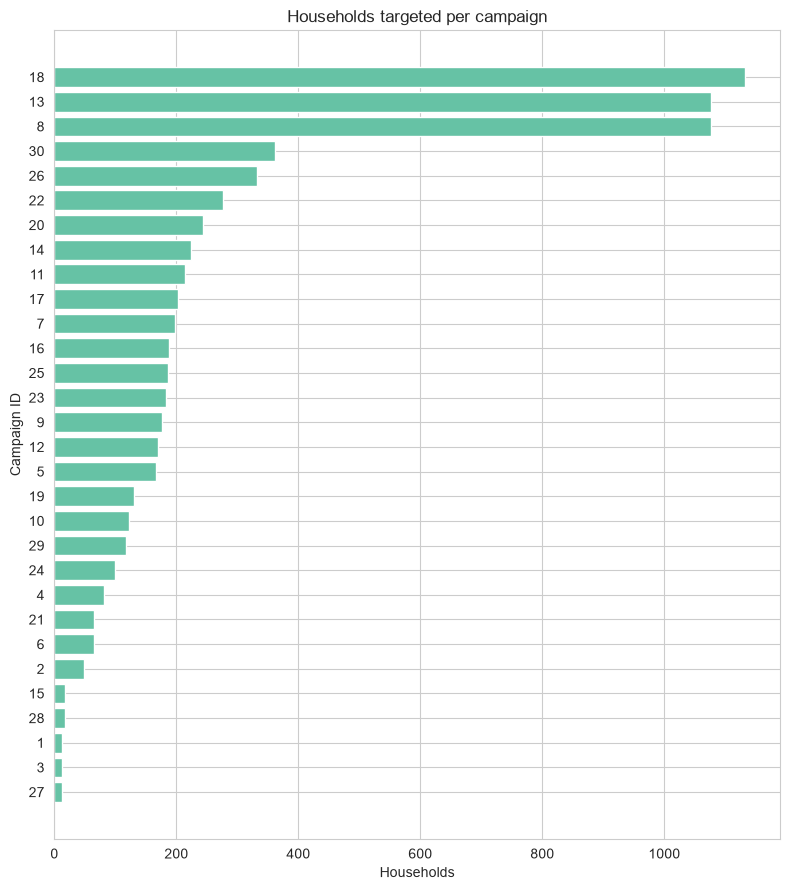

In [17]:
fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(per_campaign.index.astype(str), per_campaign.values, color=COLORS[0])
ax.invert_yaxis()
ax.set_title("Households targeted per campaign")
ax.set_xlabel("Households")
ax.set_ylabel("Campaign ID")
show_chart(fig)

### Insights: Targeted Households
The chart shows how campaign reach varies substantially across campaigns. A small number of campaigns target many more households than the rest, so household reach is a useful and defensible measure for the later Small, Medium, and Large campaign classification.

**Who are the customers (age) — baseline.** Age distribution of all households with demographic data, used to compare with the age mix of each campaign type in BQ1 Step 2 and determine whether targeted households differ from this baseline.

In [18]:
age_counts = hh_demographic["AGE_DESC"].value_counts().reindex(age_order)  # count households in each age group
df_age = pd.DataFrame({"AGE_DESC": age_counts.index, "HOUSEHOLDS": age_counts.values})
df_age_sorted = df_age.sort_values("HOUSEHOLDS", ascending=False).reset_index(drop=True)
display(df_age_sorted.head(n=5))
display(df_age.describe())


,AGE_DESC,HOUSEHOLDS
0,45-54,288
1,35-44,194
2,25-34,142
3,65+,72
4,55-64,59


,HOUSEHOLDS
count,6.000000
mean,133.500000
std,94.436751
min,46.000000
25%,62.250000
50%,107.000000
75%,181.000000
max,288.000000


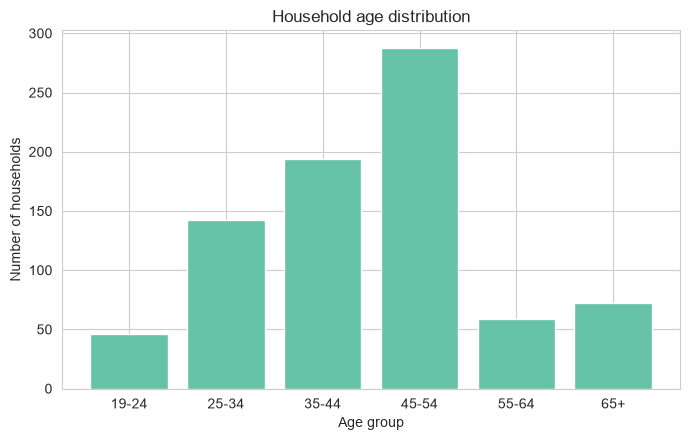

In [19]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(age_counts.index, age_counts.values, color=COLORS[0])
ax.set_title("Household age distribution")
ax.set_xlabel("Age group")
ax.set_ylabel("Number of households")
show_chart(fig)

### Insights: Household Age Distribution
The age distribution provides the baseline customer profile. The most common age groups represent the largest share of households available for targeting, while smaller groups should be interpreted cautiously when comparing campaign composition.

**Who are the customers (income) — baseline.** Similarly, this provides a baseline for comparison with the income mix in BQ1 Step 2.

In [20]:
income_order_summary = sorted(hh_demographic["INCOME_DESC"].dropna().unique(), key=income_floor)
income_summary = (
    hh_demographic["INCOME_DESC"]
    .value_counts()
    .reindex(income_order_summary)
    .rename_axis("INCOME_DESC")
    .reset_index(name="HOUSEHOLDS")
)
display(income_summary)

,INCOME_DESC,HOUSEHOLDS
0,Under 15K,61
1,15-24K,74
2,25-34K,77
3,35-49K,172
4,50-74K,192
5,75-99K,96
6,100-124K,34
7,125-149K,38
8,150-174K,30
9,175-199K,11


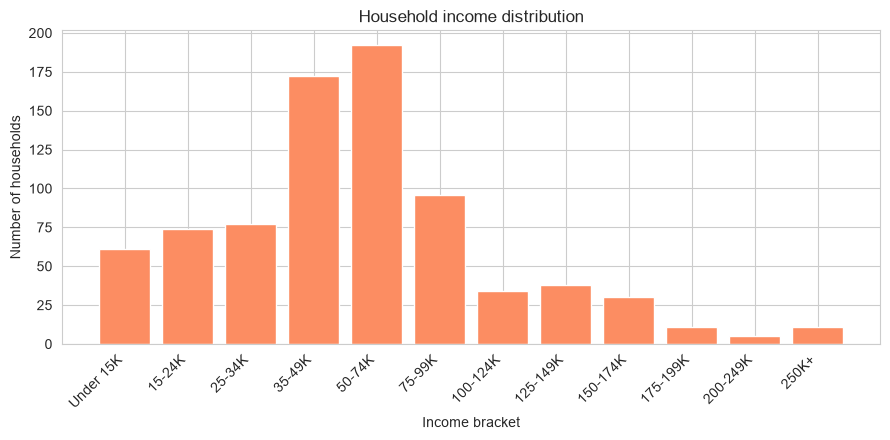

In [21]:
income_counts = hh_demographic["INCOME_DESC"].value_counts()  # count households in each income level
income_order = sorted(income_counts.index, key=income_floor)  # sort by lower income bound, from low to high

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(income_order, income_counts.reindex(income_order).values, color=COLORS[1])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_title("Household income distribution")
ax.set_xlabel("Income bracket")
ax.set_ylabel("Number of households")
show_chart(fig)

### Insights: Household Income Distribution
The income chart establishes the overall income baseline for households with demographic data. This baseline is necessary for distinguishing broad population composition from genuine differences in campaign targeting.

**What products are sold?** Catalog by department (number of SKUs) - compare with the revenue-by-department chart below: having many SKUs does not necessarily mean high revenue.

In [22]:
department_product_summary = (
    product["DEPARTMENT"]
    .value_counts()
    .head(15)
    .rename_axis("DEPARTMENT")
    .reset_index(name="N_PRODUCTS")
)
display(department_product_summary)

,DEPARTMENT,N_PRODUCTS
0,GROCERY,39021
1,DRUG GM,31529
2,PRODUCE,3118
3,COSMETICS,3011
4,NUTRITION,2914
5,MEAT,2544
6,MEAT-PCKGD,2427
7,DELI,2354
8,PASTRY,2149
9,FLORAL,938


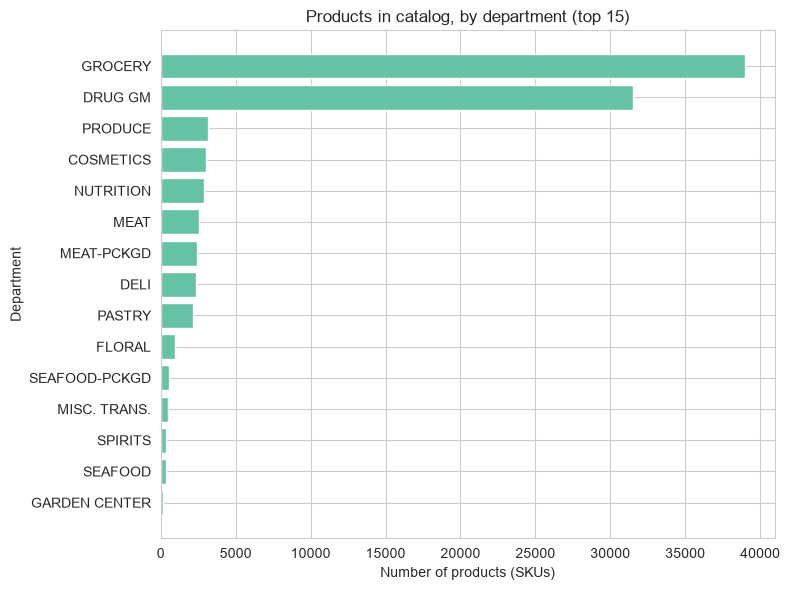

In [23]:
dept_counts = product["DEPARTMENT"].value_counts().head(15)  # count products by department, top 15

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(dept_counts.index[::-1], dept_counts.values[::-1], color=COLORS[0])
ax.set_title("Products in catalog, by department (top 15)")
ax.set_xlabel("Number of products (SKUs)")
ax.set_ylabel("Department")
show_chart(fig)

### Insights: Products by Department
The catalog is concentrated in a subset of departments. However, product count measures assortment breadth rather than sales performance, so it should be compared with the revenue chart rather than treated as a direct measure of department importance.

**Where does revenue come from?** Which departments are the main sources of revenue - compare with the catalog chart above.

In [24]:
department_revenue_summary = (
    transaction_data
    .merge(product[["PRODUCT_ID", "DEPARTMENT"]], on="PRODUCT_ID", how="left")
    .groupby("DEPARTMENT")["SALES_VALUE"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .rename("TOTAL_REVENUE")
    .rename_axis("DEPARTMENT")
    .reset_index()
)
display(department_revenue_summary)

,DEPARTMENT,TOTAL_REVENUE
0,GROCERY,4093814.14
1,DRUG GM,1055358.03
2,PRODUCE,557452.11
3,MEAT,548786.81
4,KIOSK-GAS,544222.28
5,MEAT-PCKGD,412436.77
6,DELI,260866.51
7,PASTRY,121739.86
8,MISC SALES TRAN,119960.04
9,NUTRITION,97669.04


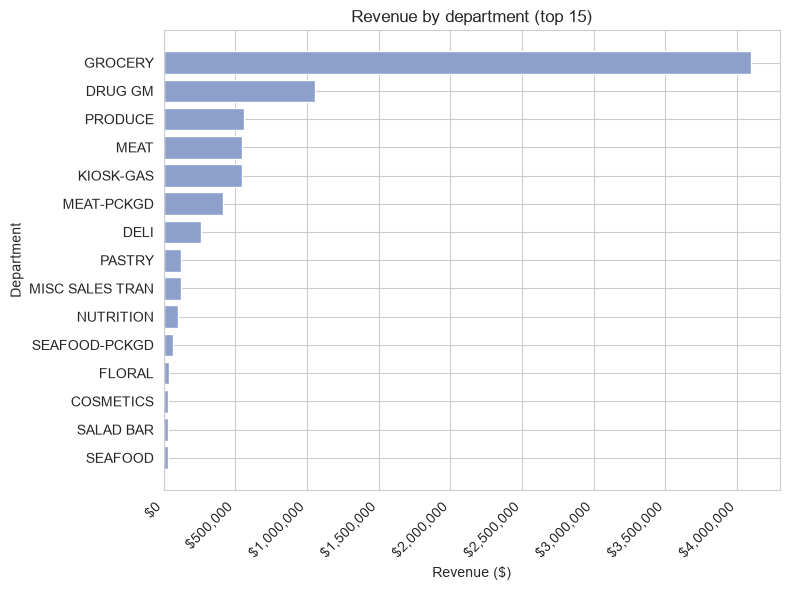

In [25]:
from matplotlib.ticker import FuncFormatter  # format the X-axis values with $ and comma separators

trans_with_dept = transaction_data.merge(product[["PRODUCT_ID", "DEPARTMENT"]], on="PRODUCT_ID", how="left")  # add the department column
dept_rev = trans_with_dept.groupby("DEPARTMENT")["SALES_VALUE"].sum().sort_values(ascending=False).head(15)  # total revenue for each department

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(dept_rev.index[::-1], dept_rev.values[::-1], color=COLORS[2])
ax.set_title("Revenue by department (top 15)")
ax.set_xlabel("Revenue ($)")
ax.set_ylabel("Department")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))  # 1750000 -> "$1,750,000" for readability
plt.xticks(rotation=45, ha='right')
show_chart(fig)

### Insights: Revenue by Department
Revenue is concentrated in the leading departments, and the ranking does not necessarily match the product-count ranking. This comparison helps identify departments with high commercial performance even when their catalog is relatively small.

**Do promotions actually increase revenue (at the product level)?** Compare average revenue when a product is featured in a display or mailer versus when it is not. This complements the main BQ1 conclusion (at the household level, Step 3) from a product-level perspective.

In [26]:
promotion_data = transaction_data.merge(
    causal_data,
    on=["PRODUCT_ID", "STORE_ID", "WEEK_NO"],
    how="inner",
)
promotion_data["on_display"] = promotion_data["display"].astype(str) != "0"
promotion_data["in_mailer"] = promotion_data["mailer"].astype(str) != "0"
display_avg_summary = promotion_data.groupby("on_display")["SALES_VALUE"].mean()
mailer_avg_summary = promotion_data.groupby("in_mailer")["SALES_VALUE"].mean()

promotion_summary = pd.DataFrame({
    "PROMOTION_STATUS": ["Not promoted", "Promoted"],
    "DISPLAY_AVG_SALES_VALUE": [display_avg_summary[False], display_avg_summary[True]],
    "MAILER_AVG_SALES_VALUE": [mailer_avg_summary[False], mailer_avg_summary[True]],
})
display(promotion_summary)

,PROMOTION_STATUS,DISPLAY_AVG_SALES_VALUE,MAILER_AVG_SALES_VALUE
0,Not promoted,2.868828,2.707254
1,Promoted,2.647367,2.781052


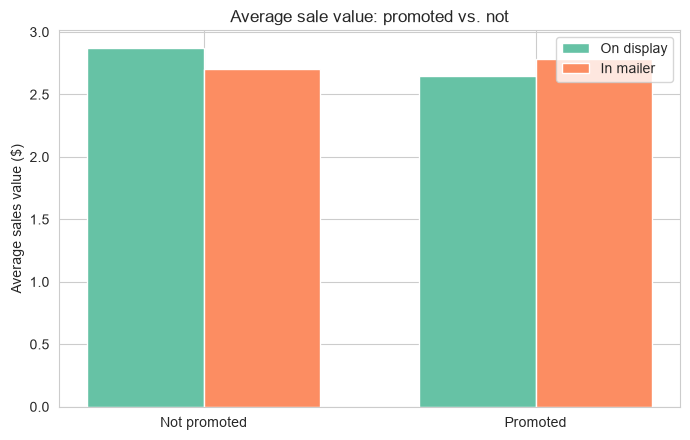

All EDA charts rendered above (no files written - display only)


In [27]:
causal = causal_data.copy()
causal["on_display"] = causal["display"].astype(str) != "0"  # "0" = not displayed, nonzero = displayed
causal["in_mailer"] = causal["mailer"].astype(str) != "0"  # same logic for mailers

causal_trans = transaction_data.merge(causal, on=["PRODUCT_ID", "STORE_ID", "WEEK_NO"], how="inner")  # join transactions with promotion information
display_avg = causal_trans.groupby("on_display")["SALES_VALUE"].mean()  # average revenue: displayed vs. not displayed
mailer_avg = causal_trans.groupby("in_mailer")["SALES_VALUE"].mean()  # average revenue: in a mailer vs. not in a mailer

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(2)
width = 0.35
ax.bar(x - width / 2, [display_avg[False], display_avg[True]], width, label="On display", color=COLORS[0])
ax.bar(x + width / 2, [mailer_avg[False], mailer_avg[True]], width, label="In mailer", color=COLORS[1])
ax.set_xticks(x)
ax.set_xticklabels(["Not promoted", "Promoted"])
ax.set_title("Average sale value: promoted vs. not")
ax.set_ylabel("Average sales value ($)")
ax.legend()
show_chart(fig)

print("All EDA charts rendered above (no files written - display only)")

### Insights: Promotion Impact
The table and chart compare average sales value when products are promoted through a display or mailer versus when they are not. Higher promoted values would indicate a positive association, but this comparison is descriptive and does not by itself establish causation.

**BQ1 - Step 2: Which customers does each campaign target?** Merge targeted households with their demographic data. Note: only 48% of targeted households have complete demographic data - the value is printed below, and the following charts use only households with available data.

In [28]:
hh_type = campaign_table[["household_key", "DESCRIPTION"]].drop_duplicates()  # one household-campaign type pair, without duplicates
targeting_demographics = hh_type.merge(hh_demographic, on="household_key", how="inner")  # keep only households with demographic data

targeted_hh_count = hh_type["household_key"].nunique()
surveyed_hh_count = targeting_demographics["household_key"].nunique()
print(f"{surveyed_hh_count} of {targeted_hh_count} targeted households have demographic data "
      f"({surveyed_hh_count / targeted_hh_count:.0%}) - charts below use only that subset")

targeting_demographics.to_csv(os.path.join(OUT_DIR, "bq1_targeting_demographics.csv"), index=False)
demo_types = sorted(targeting_demographics["DESCRIPTION"].unique())

def pct_chart(dim_col, order, title, figsize=(9, 5)):
    # % of each campaign type's households in each bracket (percentages, not raw
    # counts, since campaign types reach very different numbers of households)
    pct = pd.crosstab(targeting_demographics[dim_col], targeting_demographics["DESCRIPTION"], normalize="columns") * 100
    pct = pct.reindex(order) if order else pct
    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(pct))
    width = 0.8 / len(demo_types)
    for i, t in enumerate(demo_types):
        ax.bar(x + i * width - 0.4 + width / 2, pct[t], width, label=t, color=COLORS[i])
    ax.set_xticks(x)
    ax.set_xticklabels(pct.index, rotation=30, ha="right")
    ax.set_title(title)
    ax.set_ylabel("% of that campaign type's households")
    ax.legend(title="Campaign type")
    show_chart(fig)

760 of 1584 targeted households have demographic data (48%) - charts below use only that subset


**Compare age groups across campaign types** - which campaign types tend to target which age groups?

In [29]:
age_campaign_summary = (
    pd.crosstab(
        targeting_demographics["AGE_DESC"],
        targeting_demographics["DESCRIPTION"],
        normalize="columns",
    )
    .reindex(age_order)
    .mul(100)
    .round(1)
)
age_campaign_summary.index.name = "AGE_DESC"
display(age_campaign_summary)

DESCRIPTION,TypeA,TypeB,TypeC
AGE_DESC,,,
19-24,5.9,6.2,7.3
25-34,17.3,18.2,20.3
35-44,24.7,23.7,28.9
45-54,35.1,36.5,31.7
55-64,8.0,8.1,6.9
65+,9.0,7.3,4.9


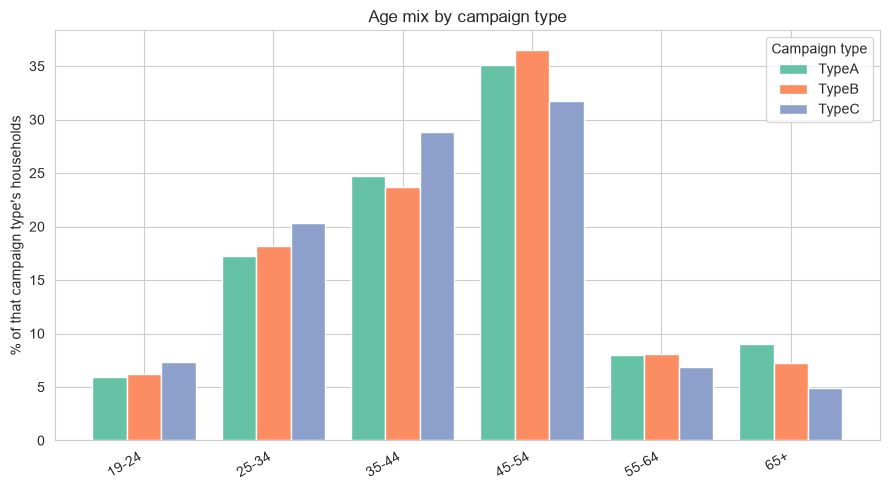

In [30]:
pct_chart("AGE_DESC", age_order, "Age mix by campaign type")

### Insights: Age Mix by Campaign Type
The percentages show whether campaign types have similar age profiles or emphasize different age groups. Comparing each campaign type with the baseline age distribution helps identify targeting patterns rather than simply reflecting the overall household population.

**Compare income levels across campaign types** - the direct answer to the first part of BQ1 (who is targeted).

In [31]:
income_campaign_order = sorted(
    targeting_demographics["INCOME_DESC"].dropna().unique(),
    key=income_floor,
)
income_campaign_summary = (
    pd.crosstab(
        targeting_demographics["INCOME_DESC"],
        targeting_demographics["DESCRIPTION"],
        normalize="columns",
    )
    .reindex(income_campaign_order)
    .mul(100)
    .round(1)
)
income_campaign_summary.index.name = "INCOME_DESC"
display(income_campaign_summary)

DESCRIPTION,TypeA,TypeB,TypeC
INCOME_DESC,,,
Under 15K,7.8,7.1,9.3
15-24K,9.0,8.5,5.7
25-34K,9.0,9.2,4.1
35-49K,21.6,21.5,24.8
50-74K,24.3,24.7,27.6
75-99K,11.7,11.6,11.8
100-124K,4.3,4.2,3.3
125-149K,5.0,5.0,4.5
150-174K,3.8,4.5,4.1


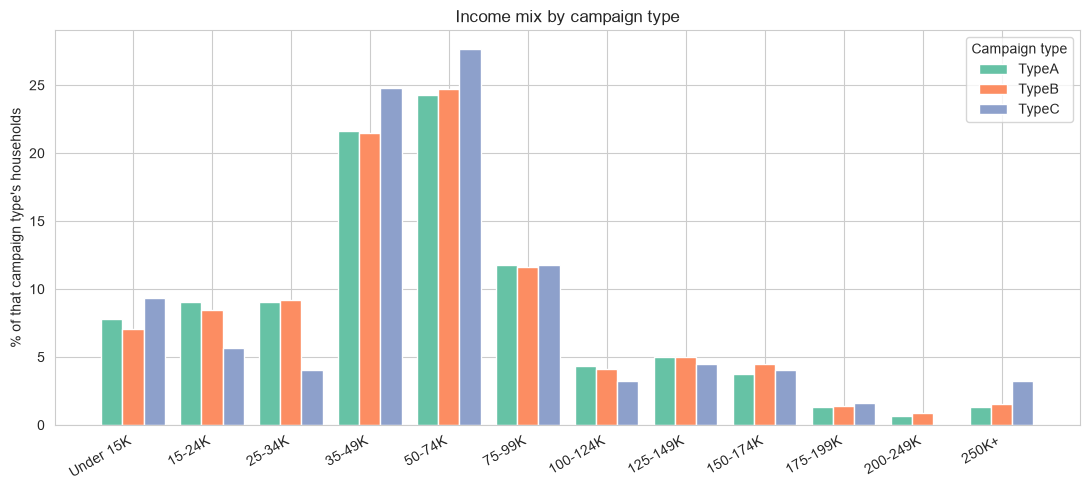

In [32]:
income_order = sorted(targeting_demographics["INCOME_DESC"].unique(), key=income_floor)
pct_chart("INCOME_DESC", income_order, "Income mix by campaign type", figsize=(11, 5))

### Insights: Income Mix by Campaign Type
The income percentages reveal whether campaign types concentrate on particular income brackets. The baseline income distribution should be used as the reference point before concluding that a campaign type over- or under-targets a group.

**BQ1 - Step 3: Prepare the spending-impact measurement.** This is the core step for answering BQ1: does spending increase while a household is in a campaign? This helper function counts the number of days a household is actually included in at least one campaign, without double-counting days when two campaigns overlap.

In [33]:
def days_covered(starts, ends):
    days = set()  # use a set to avoid double-counting overlapping days
    for start, end in zip(starts, ends):
        days.update(range(start, end + 1))
    return len(days)

**Determine the date range during which each household is targeted.** For each household, collect all campaign windows (start and end dates) for campaigns targeting that household.

In [34]:
trans = transaction_data[["household_key", "DAY", "SALES_VALUE"]]

windows = campaign_table.merge(campaign_data, on="CAMPAIGN", how="left")[["household_key", "START_DAY", "END_DAY"]]  # campaign start/end dates for each household
targeted_hh = set(windows["household_key"].unique())

campaign_days = windows.groupby("household_key").apply(  # total number of days each household is in a campaign, without overlap
    lambda g: days_covered(g["START_DAY"], g["END_DAY"])
)
study_span = trans["DAY"].max() - trans["DAY"].min() + 1  # total number of days in the full dataset
print(f"{len(targeted_hh)} targeted households, study span {study_span} days")

NameError: name 'campaign_data' is not defined

**Flag each transaction: inside or outside a campaign.** With more than 2 million transaction rows, use NumPy array comparisons (vectorization) instead of applying `.apply()` row by row.

In [ ]:
windows_by_hh = {hh: g[["START_DAY", "END_DAY"]].values for hh, g in windows.groupby("household_key")}  # group windows by household for fast lookup

flagged = []
for hh, group in trans[trans["household_key"].isin(targeted_hh)].groupby("household_key"):
    group = group.copy()
    starts, ends = windows_by_hh[hh][:, 0], windows_by_hh[hh][:, 1]
    days = group["DAY"].to_numpy()[:, None]
    group["in_campaign"] = ((days >= starts[None, :]) & (days <= ends[None, :])).any(axis=1)  # does the transaction date fall in any campaign window?
    flagged.append(group)
targeted_trans = pd.concat(flagged, ignore_index=True)

other_trans = trans[~trans["household_key"].isin(targeted_hh)].copy()
other_trans["in_campaign"] = False  # households not targeted are always considered outside a campaign
combined = pd.concat([targeted_trans, other_trans], ignore_index=True)

**Calculate average daily spending: inside versus outside campaigns, then divide into segments.** Segments are based on spending OUTSIDE campaigns (not spending during campaigns) to avoid circular logic.

In [ ]:
spend_in = combined[combined["in_campaign"]].groupby("household_key")["SALES_VALUE"].sum()  # total spending while a campaign is active
spend_out = combined[~combined["in_campaign"]].groupby("household_key")["SALES_VALUE"].sum()  # total spending outside campaigns

summary = pd.DataFrame(index=sorted(combined["household_key"].unique()))
summary["days_in_campaign"] = campaign_days.reindex(summary.index).fillna(0)
summary["days_outside_campaign"] = study_span - summary["days_in_campaign"]
summary["spend_in_campaign"] = spend_in.reindex(summary.index).fillna(0)
summary["spend_outside_campaign"] = spend_out.reindex(summary.index).fillna(0)
summary["avg_daily_spend_in_campaign"] = summary["spend_in_campaign"] / summary["days_in_campaign"]  # normalize to spending per day for a fair comparison
summary["avg_daily_spend_outside_campaign"] = summary["spend_outside_campaign"] / summary["days_outside_campaign"]

# keep only households with at least one day in a campaign
targeted_summary = summary[summary["days_in_campaign"] > 0].copy()
# spending difference: during a campaign compared with outside a campaign
targeted_summary["lift_pct"] = (
    (targeted_summary["avg_daily_spend_in_campaign"] - targeted_summary["avg_daily_spend_outside_campaign"])
    / targeted_summary["avg_daily_spend_outside_campaign"] * 100
)

# segment by OUTSIDE-campaign spend, so the segment isn't defined by the thing being measured
targeted_summary["value_segment"] = pd.qcut(
    targeted_summary["avg_daily_spend_outside_campaign"], q=4,
    labels=["Low value", "Med-low value", "Med-high value", "High value"],
)

targeted_summary.to_csv(os.path.join(OUT_DIR, "bq1_campaign_spending_impact.csv"), index_label="household_key")
print(f"{len(targeted_summary)} targeted households with a valid in/out comparison")

1584 targeted households with a valid in/out comparison


**BQ1 conclusion: spending lift by segment.** This chart provides the main answer to BQ1: which segment increases spending the most when a campaign is active? The horizontal line at 0 marks "no change" for comparison.

In [ ]:
spending_lift_summary = (
    targeted_summary.groupby("value_segment", observed=True)
    .agg(
        HOUSEHOLDS=("lift_pct", "size"),
        AVG_DAILY_SPEND_IN_CAMPAIGN=("avg_daily_spend_in_campaign", "mean"),
        AVG_DAILY_SPEND_OUTSIDE_CAMPAIGN=("avg_daily_spend_outside_campaign", "mean"),
        AVG_LIFT_PCT=("lift_pct", "mean"),
    )
    .round(2)
    .reset_index()
)
display(spending_lift_summary)

,value_segment,HOUSEHOLDS,AVG_DAILY_SPEND_IN_CAMPAIGN,AVG_DAILY_SPEND_OUTSIDE_CAMPAIGN,AVG_LIFT_PCT
0,Low value,396,2.20,2.07,8.22
1,Med-low value,396,4.34,3.73,16.53
2,Med-high value,396,7.51,6.03,25.55
3,High value,396,14.11,12.13,17.47


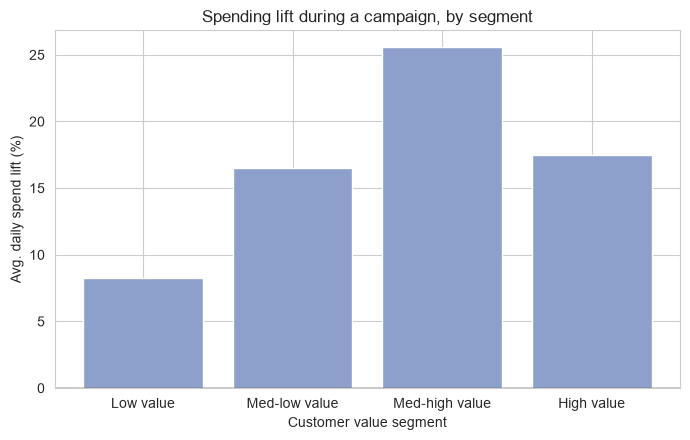

All BQ1 CSV outputs saved to: outputs (charts rendered above only)


In [ ]:
seg_order = ["Low value", "Med-low value", "Med-high value", "High value"]

lift_by_seg = targeted_summary.groupby("value_segment", observed=True)["lift_pct"].mean().reindex(seg_order)  # average lift percentage for each segment

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(lift_by_seg.index, lift_by_seg.values, color=COLORS[2])
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Spending lift during a campaign, by segment")
ax.set_xlabel("Customer value segment")
ax.set_ylabel("Avg. daily spend lift (%)")
show_chart(fig)

print(f"All BQ1 CSV outputs saved to: {OUT_DIR} (charts rendered above only)")

### Insights: Spending Lift by Segment
The spending-lift table and chart compare average daily spending during campaigns with spending outside campaigns for each customer-value segment. Positive values indicate higher spending during campaigns, while negative values indicate lower spending; the segment definition is based only on outside-campaign spending.

**Q1 - Output 1: campaign summary table** - includes all 30 campaigns, including campaigns with 0 coupons or households ("Do not drop anything, no duplicates"). All calculations use `reindex` + `fillna(0)` instead of an inner join. This section is independent and does not require BQ1 to be run first.

In [ ]:
# "Do not drop anything (no duplicates)": all 30 campaigns must appear
# in the table below, including campaigns with 0 coupons or 0 households - therefore every lookup
# is reindexed to the full campaign list and then filled with 0 instead of using an inner join
# (an inner join could drop campaigns without a match).
all_campaigns = campaign_data.drop_duplicates(subset="CAMPAIGN").set_index("CAMPAIGN")
campaign_summary = all_campaigns[["DESCRIPTION", "START_DAY", "END_DAY"]].rename(
    columns={"DESCRIPTION": "CAMPAIGN_TYPE"}
)
campaign_summary["DURATION_DAYS"] = all_campaigns["END_DAY"] - all_campaigns["START_DAY"] + 1

households_per_campaign = campaign_table.groupby("CAMPAIGN")["household_key"].nunique()  # number of distinct households per campaign
coupons_per_campaign = coupon_table.groupby("CAMPAIGN")["COUPON_UPC"].nunique()  # number of distinct coupons per campaign
products_per_campaign = coupon_table.groupby("CAMPAIGN")["PRODUCT_ID"].nunique()  # number of distinct products per campaign

# join coupon_table with product to get the department, then count the number of distinct departments per
# campaign - do this independently instead of using campaign_product_map (BQ1 Step 1), so Q1 does not depend on BQ1
coupon_with_dept = coupon_table.merge(product[["PRODUCT_ID", "DEPARTMENT"]], on="PRODUCT_ID", how="left")
categories_per_campaign = coupon_with_dept.groupby("CAMPAIGN")["DEPARTMENT"].nunique()  # number of distinct departments per campaign

campaign_summary["N_HOUSEHOLDS_TARGETED"] = households_per_campaign.reindex(campaign_summary.index).fillna(0).astype(int)
campaign_summary["N_COUPONS"] = coupons_per_campaign.reindex(campaign_summary.index).fillna(0).astype(int)
campaign_summary["N_PRODUCTS"] = products_per_campaign.reindex(campaign_summary.index).fillna(0).astype(int)
campaign_summary["N_CATEGORIES"] = categories_per_campaign.reindex(campaign_summary.index).fillna(0).astype(int)

# "revenue associated with the campaign period" = total sales during the campaign's date range,
# calculated across all households (campaigns can overlap in time, so one transaction
# may legitimately be counted for more than one campaign)
revenue_per_campaign = {
    camp: transaction_data.loc[
        (transaction_data["DAY"] >= row["START_DAY"]) & (transaction_data["DAY"] <= row["END_DAY"]), "SALES_VALUE"
    ].sum()
    for camp, row in campaign_summary.iterrows()
}
campaign_summary["TOTAL_REVENUE"] = pd.Series(revenue_per_campaign)

campaign_summary.to_csv(os.path.join(OUT_DIR, "q1_campaign_summary.csv"))
print(f"{len(campaign_summary)} campaigns in the table (should be 30 - none dropped)")
campaign_summary

30 campaigns in the table (should be 30 - none dropped)


,CAMPAIGN_TYPE,START_DAY,END_DAY,DURATION_DAYS,N_HOUSEHOLDS_TARGETED,N_COUPONS,N_PRODUCTS,N_CATEGORIES,TOTAL_REVENUE
CAMPAIGN,,,,,,,,,
24,TypeB,659,719,61,100,2,1887,4,692074.73
15,TypeC,547,708,162,17,2,55,1,2092165.30
25,TypeB,659,691,33,187,17,826,5,442635.75
20,TypeC,615,685,71,244,24,609,2,938703.05
23,TypeB,646,684,39,183,18,767,3,518152.94
21,TypeB,624,656,33,65,16,242,6,445814.41
22,TypeB,624,656,33,276,21,1917,4,445814.41
18,TypeA,587,642,56,1133,209,35513,28,751569.98
19,TypeB,603,635,33,130,11,375,1,430047.30


**Q1 - Output 2: Small/Medium/Large classification** - use the number of targeted households (reach) as the criterion, divide campaigns into three equally sized groups with `qcut`, choose the campaign closest to the median in each group as its representative, and add examples with the highest and lowest revenue.

In [ ]:
# Chosen metric: number of households targeted (= campaign reach). It's a direct,
# easy-to-defend measure of "size" and it already varies a lot between campaigns
# (see the campaign_table_01 chart above) - split into 3 equal-sized groups by reach.
campaign_summary["SIZE"] = pd.qcut(
    campaign_summary["N_HOUSEHOLDS_TARGETED"], q=3, labels=["Small", "Medium", "Large"]
)

def pick_typical(bucket):
    # the campaign closest to the bucket's own median reach - more representative
    # than an arbitrary first row or a random pick
    median_reach = bucket["N_HOUSEHOLDS_TARGETED"].median()
    return (bucket["N_HOUSEHOLDS_TARGETED"] - median_reach).abs().idxmin()

examples = {
    size: pick_typical(campaign_summary[campaign_summary["SIZE"] == size])
    for size in ["Small", "Medium", "Large"]
}
examples["Highest-revenue"] = campaign_summary["TOTAL_REVENUE"].idxmax()
examples["Lowest-revenue"] = campaign_summary["TOTAL_REVENUE"].idxmin()

for label, camp in examples.items():
    print(f"{label} example: campaign {camp}")

campaign_summary.loc[list(examples.values())]

Small example: campaign 15
Medium example: campaign 12
Large example: campaign 22
Highest-revenue example: campaign 15
Lowest-revenue example: campaign 4


,CAMPAIGN_TYPE,START_DAY,END_DAY,DURATION_DAYS,N_HOUSEHOLDS_TARGETED,N_COUPONS,N_PRODUCTS,N_CATEGORIES,TOTAL_REVENUE,SIZE
CAMPAIGN,,,,,,,,,,
15,TypeC,547,708,162,17,2,55,1,2092165.30,Small
12,TypeB,477,509,33,170,15,620,3,415911.01,Medium
22,TypeB,624,656,33,276,21,1917,4,445814.41,Large
15,TypeC,547,708,162,17,2,55,1,2092165.30,Small
4,TypeB,372,404,33,81,12,200,2,406075.38,Small


# Q2: Understanding The Customers

Description: Now that we have an understanding of the campaigns, let's try to understand the impact of selected campaigns on its targeted customers.

Process for Q2:
1. Step 1: Connect the campaigns desc, table, and hh demographic to for a joint campaigns demographic table
2. Step 2: Connect the joint table with transaction data to understand the purchase frequency
3. Step 3: Summary table for household + household transaction
4. Step 4: Visualizations (e.g bar chart) to understand distribution based on various categorical variables (marital status, age group,...)
5. Step 5: Since transaction data is large, run a regression between two quantitative variables (TBD) with categorical variables to see if there is any association among chosen variables that could inform Q3, which is about spending changes. 

In [38]:
#Merge campaign desc with campaign table to get the campaign type for each household

merged_campaign_table = campaign_table.merge(campaign_desc, on=["CAMPAIGN","DESCRIPTION"], how="left")

display(merged_campaign_table.head(n=5))
print(f"Total households in merged_campaign_table: {merged_campaign_table['household_key'].nunique()}")
print(merged_campaign_table.info())


,DESCRIPTION,household_key,CAMPAIGN,START_DAY,END_DAY
0,TypeA,17,26,224,264
1,TypeA,27,26,224,264
2,TypeA,212,26,224,264
3,TypeA,208,26,224,264
4,TypeA,192,26,224,264


Total households in merged_campaign_table: 1584
<class 'pandas.DataFrame'>
RangeIndex: 7208 entries, 0 to 7207
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   DESCRIPTION    7208 non-null   str  
 1   household_key  7208 non-null   int64
 2   CAMPAIGN       7208 non-null   int64
 3   START_DAY      7208 non-null   int64
 4   END_DAY        7208 non-null   int64
dtypes: int64(4), str(1)
memory usage: 281.7 KB
None


In [54]:
hh_demographic_with_campaign = hh_demographic.merge(merged_campaign_table, on=["household_key"], how="left")
hh_demographic_with_campaign["DURATION"] = hh_demographic_with_campaign["END_DAY"] - hh_demographic_with_campaign["START_DAY"] + 1
hh_demographic_with_campaign = hh_demographic_with_campaign.rename(columns={"DESCRIPTION": "CAMPAIGN_TYPE"})
display(hh_demographic_with_campaign.head(n=5))
print(f"Total households in hh_demographic_with_campaign: {hh_demographic_with_campaign['household_key'].nunique()}")
print(hh_demographic_with_campaign.info())

,AGE_DESC,MARITAL_STATUS_CODE,INCOME_DESC,HOMEOWNER_DESC,HH_COMP_DESC,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC,household_key,CAMPAIGN_TYPE,CAMPAIGN,START_DAY,END_DAY,DURATION
0,65+,A,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown,1,TypeA,8.0,412.0,460.0,49.0
1,65+,A,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown,1,TypeA,13.0,504.0,551.0,48.0
2,65+,A,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown,1,TypeA,18.0,587.0,642.0,56.0
3,65+,A,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown,1,TypeB,29.0,281.0,334.0,54.0
4,65+,A,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown,1,TypeB,12.0,477.0,509.0,33.0


Total households in hh_demographic_with_campaign: 801
<class 'pandas.DataFrame'>
RangeIndex: 4254 entries, 0 to 4253
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   AGE_DESC             4254 non-null   str    
 1   MARITAL_STATUS_CODE  4254 non-null   str    
 2   INCOME_DESC          4254 non-null   str    
 3   HOMEOWNER_DESC       4254 non-null   str    
 4   HH_COMP_DESC         4254 non-null   str    
 5   HOUSEHOLD_SIZE_DESC  4254 non-null   str    
 6   KID_CATEGORY_DESC    4254 non-null   str    
 7   household_key        4254 non-null   int64  
 8   CAMPAIGN_TYPE        4213 non-null   str    
 9   CAMPAIGN             4213 non-null   float64
 10  START_DAY            4213 non-null   float64
 11  END_DAY              4213 non-null   float64
 12  DURATION             4213 non-null   float64
dtypes: float64(4), int64(1), str(8)
memory usage: 432.2 KB
None


In [55]:
hh_demographic_with_campaign = hh_demographic_with_campaign.rename(columns={"DESCRIPTION": "CAMPAIGN_TYPE"})

#### Characteristics 1: Marital Status

In [56]:
grouped_by_martital= pd.DataFrame(hh_demographic_with_campaign.groupby("CAMPAIGN_TYPE")["MARITAL_STATUS_CODE"].value_counts(normalize=True).rename("PERCENTAGE").reset_index())
display(grouped_by_martital)

,CAMPAIGN_TYPE,MARITAL_STATUS_CODE,PERCENTAGE
0,TypeA,U,0.427260
1,TypeA,A,0.423130
2,TypeA,B,0.149610
3,TypeB,A,0.449163
4,TypeB,U,0.399522
5,TypeB,B,0.151316
6,TypeC,A,0.453039
7,TypeC,U,0.430939
8,TypeC,B,0.116022


C:\Users\mclma\AppData\Local\Temp\ipykernel_20268\3840955605.py:2: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.barplot(data=grouped_by_martital, x="CAMPAIGN_TYPE", y="PERCENTAGE", hue="MARITAL_STATUS_CODE", ax=ax, palette=COLORS)


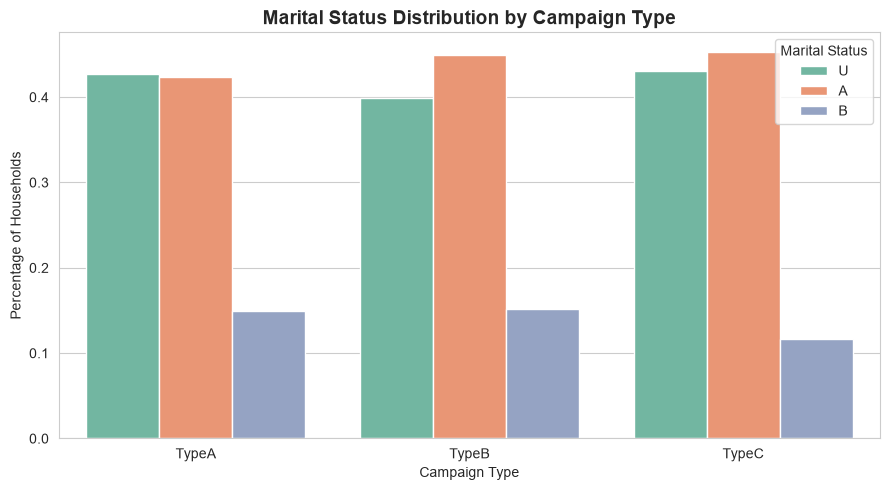

In [57]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=grouped_by_martital, x="CAMPAIGN_TYPE", y="PERCENTAGE", hue="MARITAL_STATUS_CODE", ax=ax, palette=COLORS)
ax.set_title("Marital Status Distribution by Campaign Type",fontweight='bold', fontsize=14)
ax.set_xlabel("Campaign Type")
ax.set_ylabel("Percentage of Households")
ax.legend(title="Marital Status")
plt.tight_layout()

#### Characteristics 2: Household Composition

In [58]:
grouped_by_hhcomps =  pd.DataFrame(hh_demographic_with_campaign.groupby("CAMPAIGN_TYPE")["HH_COMP_DESC"].value_counts(normalize=True).rename("PERCENTAGE").reset_index())
display(grouped_by_hhcomps)

,CAMPAIGN_TYPE,HH_COMP_DESC,PERCENTAGE
0,TypeA,2 Adults No Kids,0.321707
1,TypeA,2 Adults Kids,0.222120
2,TypeA,Single Female,0.182653
3,TypeA,Single Male,0.115190
4,TypeA,Unknown,0.100046
5,TypeA,1 Adult Kids,0.058284
6,TypeB,2 Adults No Kids,0.308014
7,TypeB,2 Adults Kids,0.287679
8,TypeB,Single Female,0.155502
9,TypeB,Single Male,0.096292


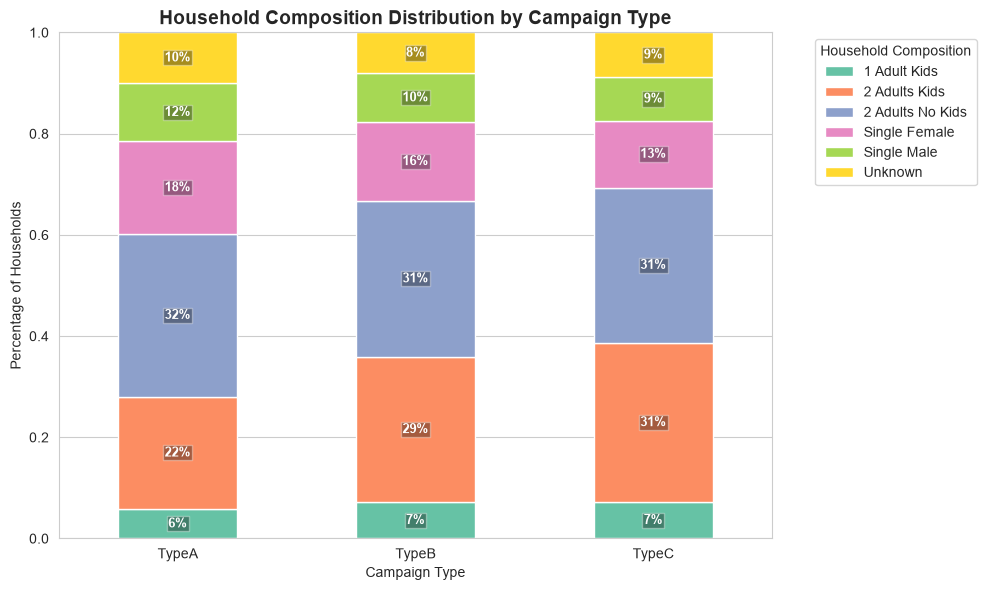

In [76]:
stacked_bar_data = grouped_by_hhcomps.pivot(index='CAMPAIGN_TYPE', columns='HH_COMP_DESC', values='PERCENTAGE').fillna(0)
ax = stacked_bar_data.plot(kind='bar', stacked=True, figsize=(10, 6), color=COLORS)
ax.set_title("Household Composition Distribution by Campaign Type", fontweight='bold', fontsize=14)
ax.set_xlabel('Campaign Type')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_ylabel('Percentage of Households')
ax.set_ylim(0, 1)
for containers in ax.containers:
    labels = [f'{value:.0%}' if value >= 0.05 else '' for value in containers.datavalues]
    ax.bar_label(containers, labels=labels, label_type='center', fontsize=9, fontweight='bold', color='white', bbox={'facecolor': 'black', 'alpha': 0.35, 'pad': 1})

ax.legend(title='Household Composition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

#### Characteristic 3: Income

In [87]:
grouped_by_income = pd.DataFrame(hh_demographic_with_campaign.groupby("CAMPAIGN_TYPE")["INCOME_DESC"].value_counts(normalize=True).rename("PERCENTAGE").reset_index())
order = ["Under 15K", "15-24K","25-34K", "35-49K", "50-74K", "75-99K", "100-124K", "125-149K", "150-174K", "175-199K", "200-249K", "250K+"]
grouped_by_income['INCOME_DESC'] = pd.Categorical(grouped_by_income['INCOME_DESC'], categories=order, ordered=True)
grouped_by_income = grouped_by_income.sort_values(['CAMPAIGN_TYPE', 'INCOME_DESC'])
display(grouped_by_income)

,CAMPAIGN_TYPE,INCOME_DESC,PERCENTAGE
5,TypeA,Under 15K,0.078935
3,TypeA,15-24K,0.094080
4,TypeA,25-34K,0.092244
1,TypeA,35-49K,0.208352
0,TypeA,50-74K,0.250574
2,TypeA,75-99K,0.111978
7,TypeA,100-124K,0.043598
6,TypeA,125-149K,0.050023
8,TypeA,150-174K,0.038550
10,TypeA,175-199K,0.009637


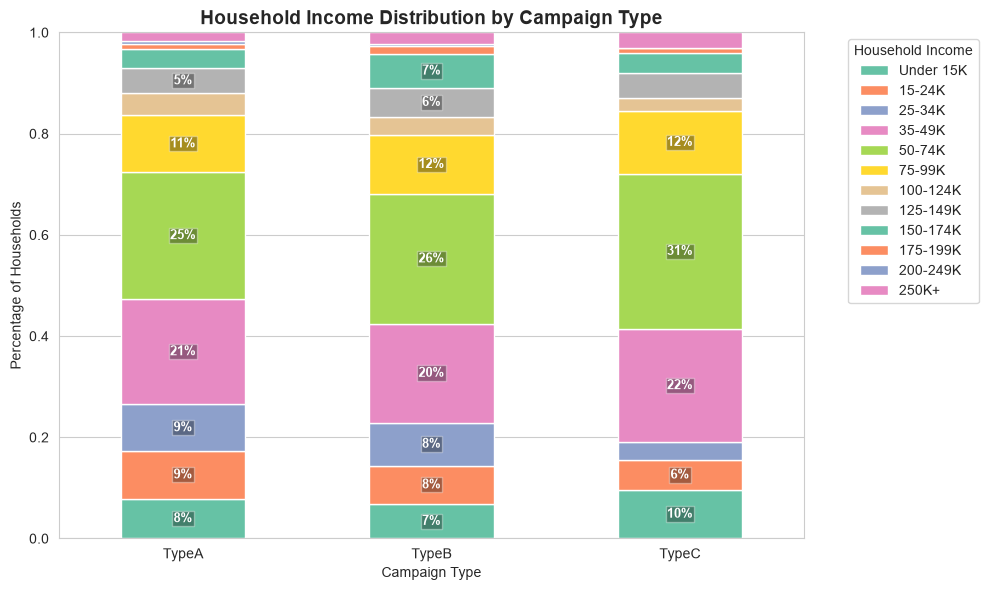

In [89]:
stacked_bar_data =grouped_by_income.pivot(index='CAMPAIGN_TYPE', columns='INCOME_DESC', values='PERCENTAGE').fillna(0)
ax = stacked_bar_data.plot(kind='bar', stacked=True, figsize=(10, 6), color=COLORS)
ax.set_title("Household Income Distribution by Campaign Type", fontweight='bold', fontsize=14)
ax.set_xlabel('Campaign Type')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_ylabel('Percentage of Households')
ax.set_ylim(0, 1)
for containers in ax.containers:
    labels = [f'{value:.0%}' if value >= 0.05 else '' for value in containers.datavalues]
    ax.bar_label(containers, labels=labels, label_type='center', fontsize=9, fontweight='bold', color='white', bbox={'facecolor': 'black', 'alpha': 0.35, 'pad': 1})


ax.legend(title='Household Income', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

#### Characteristic 4: Age

In [92]:
grouped_by_age = pd.DataFrame(hh_demographic_with_campaign.groupby("CAMPAIGN_TYPE")["AGE_DESC"].value_counts(normalize=True).rename("PERCENTAGE").reset_index())
age_order = ["19-24", "25-34", "35-44", "45-54", "55-64", "65+"]
grouped_by_age['AGE_DESC'] = pd.Categorical(grouped_by_age['AGE_DESC'], categories=age_order, ordered=True)
grouped_by_age = grouped_by_age.sort_values(['CAMPAIGN_TYPE', 'AGE_DESC']).reset_index(drop=True)
display(grouped_by_age)

,CAMPAIGN_TYPE,AGE_DESC,PERCENTAGE
0,TypeA,19-24,0.057825
1,TypeA,25-34,0.172556
2,TypeA,35-44,0.250574
3,TypeA,45-54,0.353832
4,TypeA,55-64,0.081230
5,TypeA,65+,0.083983
6,TypeB,19-24,0.055622
7,TypeB,25-34,0.212321
8,TypeB,35-44,0.277512
9,TypeB,45-54,0.337919


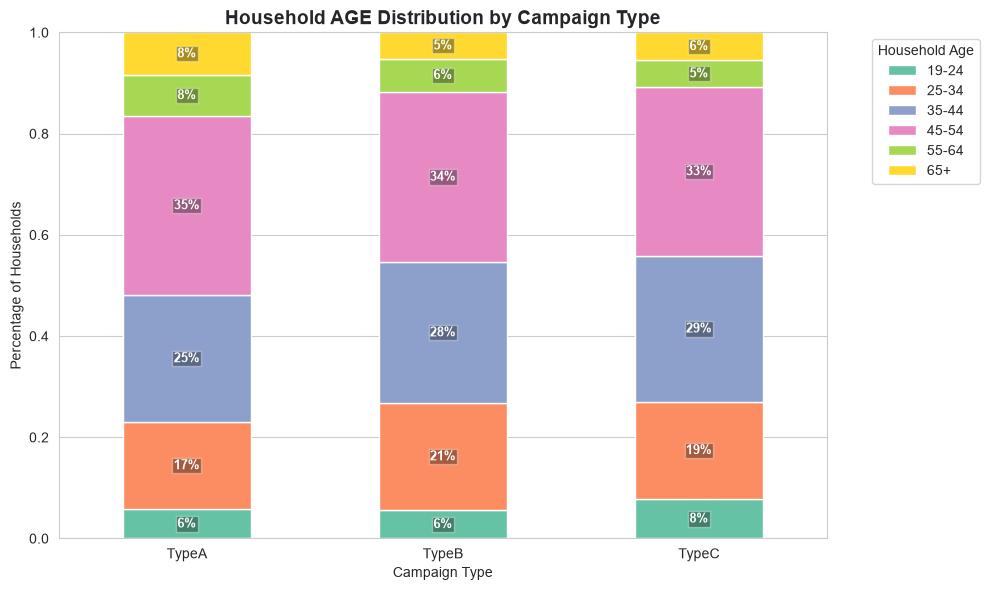

In [95]:
stacked_bar_data = grouped_by_age.pivot(index='CAMPAIGN_TYPE', columns='AGE_DESC', values='PERCENTAGE').fillna(0)
ax = stacked_bar_data.plot(kind='bar', stacked=True, figsize=(10, 6), color=COLORS)
ax.set_title("Household AGE Distribution by Campaign Type", fontweight='bold', fontsize=14)
ax.set_xlabel('Campaign Type')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_ylabel('Percentage of Households')
ax.set_ylim(0, 1)
for containers in ax.containers:
    labels = [f'{value:.0%}' if value >= 0.05 else '' for value in containers.datavalues]
    ax.bar_label(containers, labels=labels, label_type='center', fontsize=9, fontweight='bold', color='white', bbox={'facecolor': 'black', 'alpha': 0.35, 'pad': 1})


ax.legend(title='Household Age', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()